📌 Project Title

Unemployment Analysis in India During COVID-19 Using Python

🧾1: Import Libraries

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

📂 2: Load Datasets

In [42]:
df1 = pd.read_csv("datasets/Unemployment in India.csv")
df2 = pd.read_csv("datasets/Unemployment_Rate_upto_11_2020.csv")

🧹 3: Data Cleaning

In [43]:
# Remove extra spaces in column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Drop unnecessary columns
df2 = df2.drop(columns=['Region.1', 'longitude', 'latitude'], errors='ignore')

# Convert Date column
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

# Combine both datasets
df = pd.concat([df1, df2])
# Sort by date
df = df.sort_values(by='Date')

# Drop missing values
df = df.dropna()



In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 188
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
 7   Period                                   740 non-null    object        
 8   Month                                    740 non-null    int32         
dtypes: datetime64[ns](1), float64(3), int32(1), objec

In [54]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Period,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,Before COVID,5
133,Jharkhand,2019-05-31,Monthly,7.11,7035766.0,39.04,Rural,Before COVID,5
122,Jammu & Kashmir,2019-05-31,Monthly,12.78,2495186.0,40.57,Rural,Before COVID,5
561,Madhya Pradesh,2019-05-31,Monthly,3.91,6692720.0,38.96,Urban,Before COVID,5
108,Himachal Pradesh,2019-05-31,Monthly,13.68,2045760.0,44.23,Rural,Before COVID,5


In [55]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Period,Month
739,Uttarakhand,2020-06-30,Monthly,5.08,989470.0,35.61,Urban,During COVID,6
331,Uttar Pradesh,2020-06-30,Monthly,8.51,41908909.0,36.89,Rural,During COVID,6
344,Uttarakhand,2020-06-30,Monthly,10.71,1675441.0,32.00,Rural,During COVID,6
615,Odisha,2020-06-30,Monthly,2.18,2221069.0,35.24,Urban,During COVID,6
188,Madhya Pradesh,2020-06-30,Monthly,6.46,16748971.0,41.50,Rural,During COVID,6


🧠  4: Feature Engineering

In [45]:
# Create COVID period column
df['Period'] = df['Date'].apply(lambda x: "Before COVID" if x.year < 2020 else "During COVID")

# Extract Month
df['Month'] = df['Date'].dt.month

📊  5: Data Analysis & Visualization

***1️⃣ Unemployment Trend Over Time***

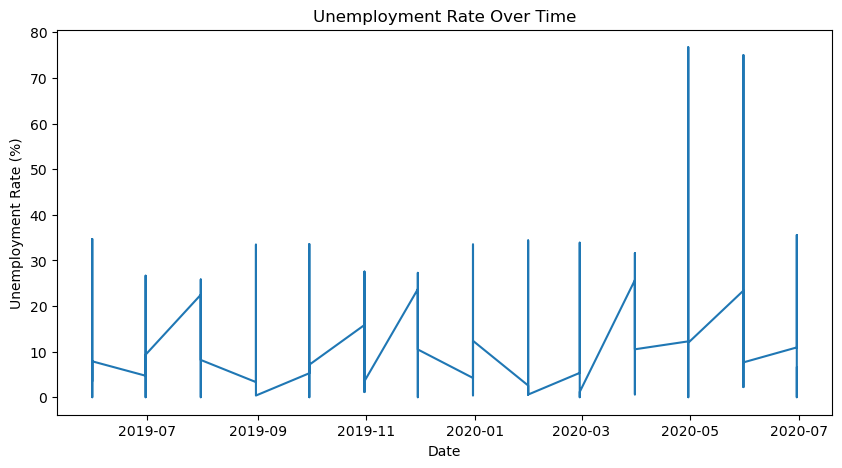

In [46]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

2️⃣ Before vs During COVID

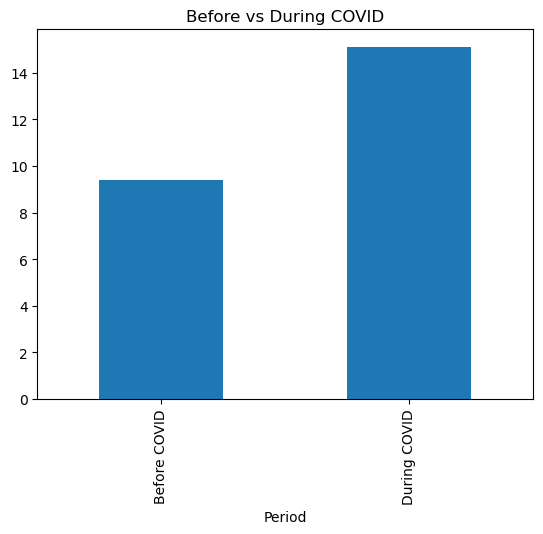

In [47]:
df.groupby('Period')['Estimated Unemployment Rate (%)'].mean().plot(kind='bar')
plt.title("Before vs During COVID")
plt.show()

3️⃣ State-wise Unemployment

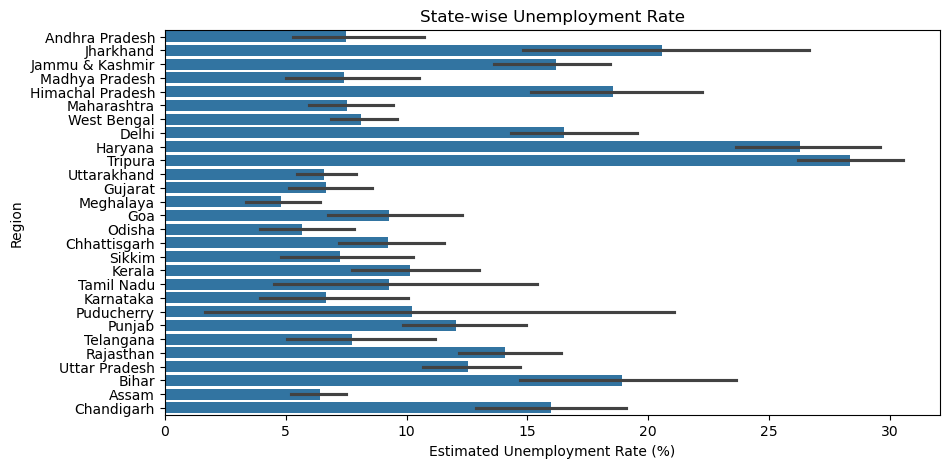

In [48]:
plt.figure(figsize=(10,5))
sns.barplot(x='Estimated Unemployment Rate (%)', y='Region', data=df)
plt.title("State-wise Unemployment Rate")
plt.show()

4️⃣ Urban vs Rural Analysis

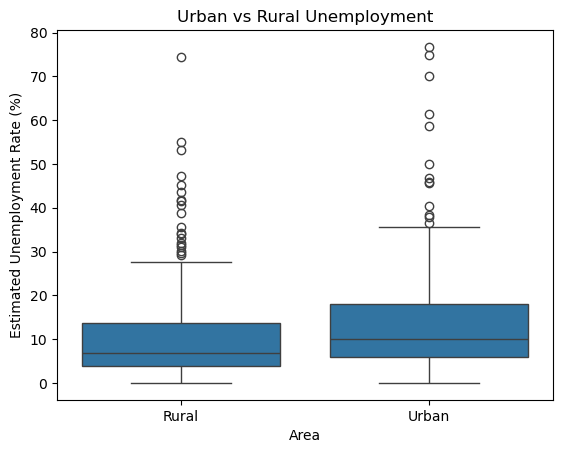

In [49]:
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Urban vs Rural Unemployment")
plt.show()

5️⃣ Monthly / Seasonal Trends

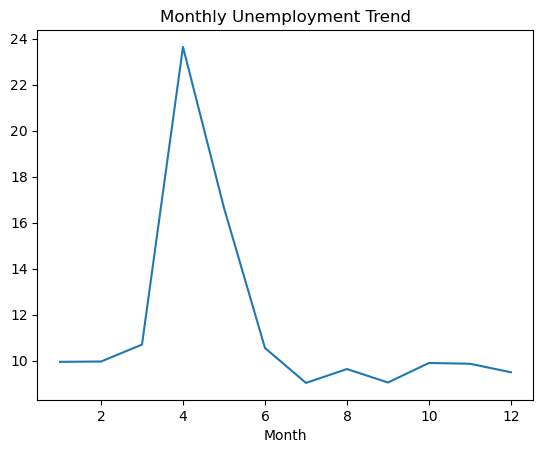

In [50]:
df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().plot()
plt.title("Monthly Unemployment Trend")
plt.show()

Highlight Lockdown Period

In [51]:
lockdown = df[(df['Date'] >= '2020-04-01') & (df['Date'] <= '2020-06-30')]

print(lockdown['Estimated Unemployment Rate (%)'].mean())

20.194342105263157
